# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,  mean_absolute_error, r2_score


In [4]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


(701548, 6)

## Exploratory Data Analysis


In [5]:
# Check for missing values
print("Null values :", df.isnull().sum())
# Display summary statistics
df.describe()


Null values : sensor_id      0
lat            0
lon            0
pressure       0
temperature    0
humidity       0
dtype: int64


,sensor_id,lat,lon,pressure,temperature,humidity
count,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000
mean,2835.419842,42.679722,23.333739,94965.292500,24.754990,48.348949
std,798.018890,0.025568,0.039365,2577.210945,14.013001,20.907247
min,1764.000000,42.622000,23.240000,0.000000,-145.120000,0.000000
25%,2224.000000,42.665000,23.310000,94528.017500,20.630000,34.140000
50%,2323.000000,42.685000,23.332000,95005.480000,24.780000,48.350000
75%,3474.000000,42.694000,23.360000,95405.132500,29.870000,62.940000
max,4661.000000,42.738000,23.419000,164926.750000,61.170000,100.000000


## Duplicate Values

In [6]:
df.duplicated().sum()
df = df.drop_duplicates()

In [7]:
# Scatter plot to observe relationship

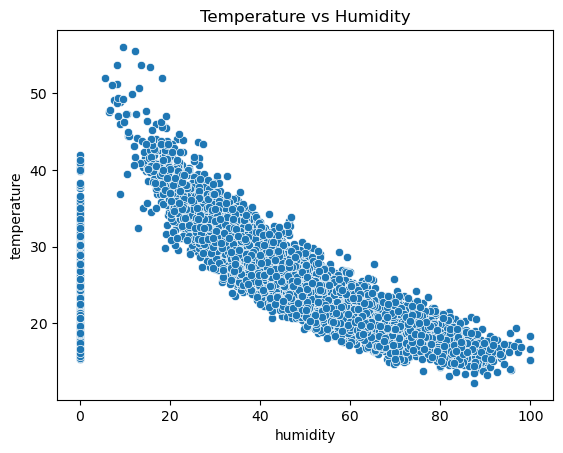

In [8]:
sns.scatterplot(x='humidity', y='temperature', data=df.sample(5000))
plt.title("Temperature vs Humidity")
plt.show()

In [9]:
# Histogram

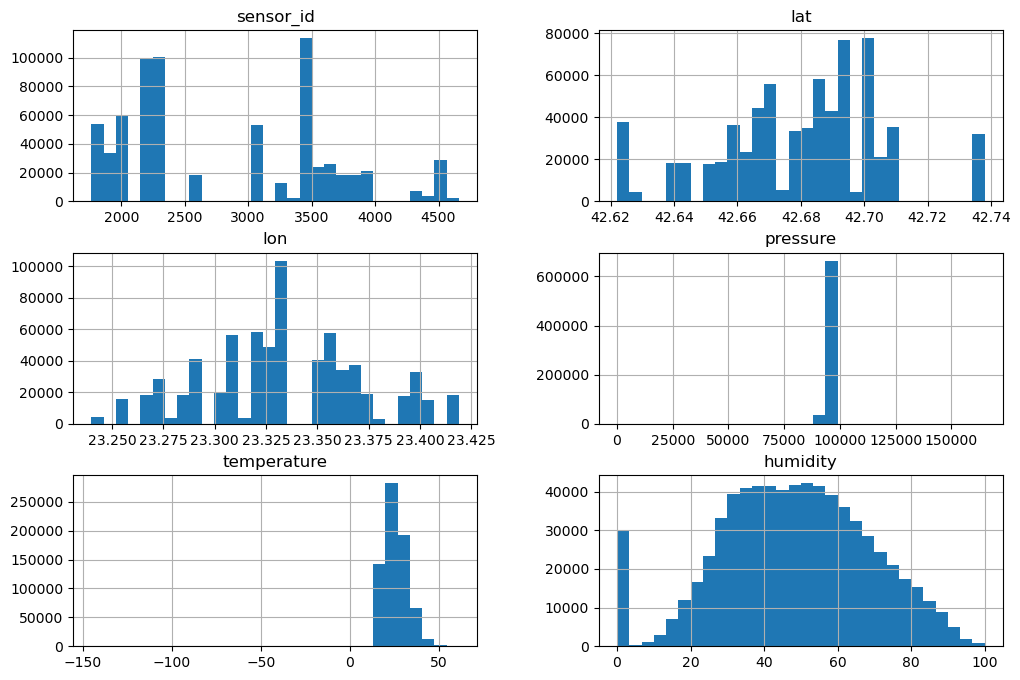

In [10]:
df.hist(figsize=(12,8), bins=30)
plt.show()

## Outlier Detection

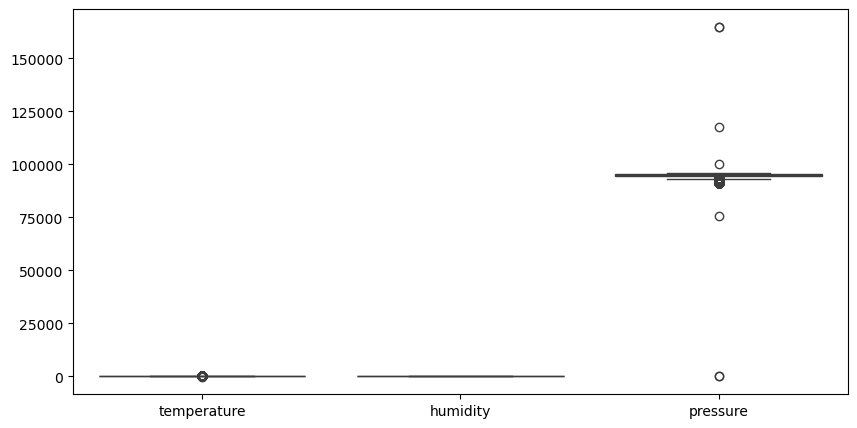

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['temperature','humidity','pressure']])
plt.show()

In [12]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [13]:
df.shape

(663568, 6)

## Correlation Analysis

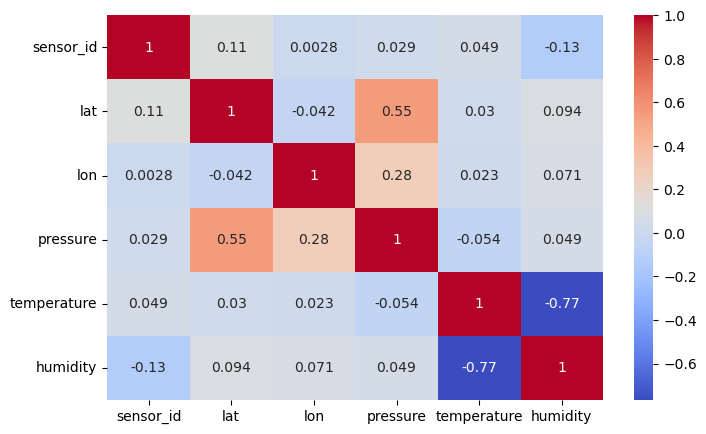

In [14]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

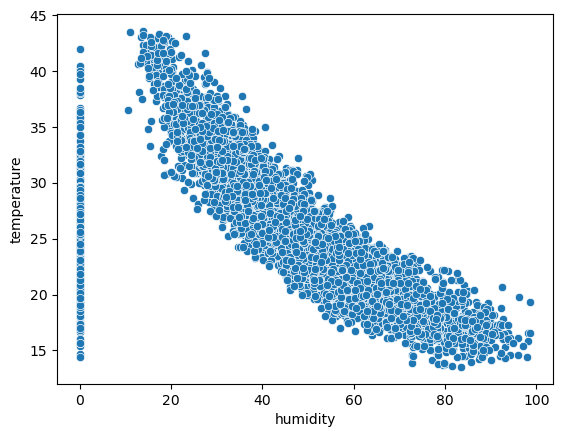

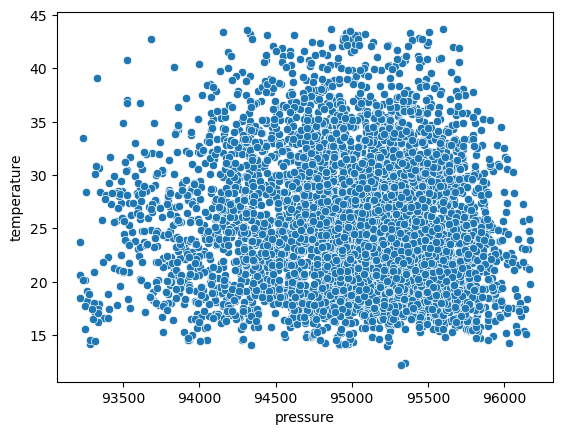

In [15]:
sns.scatterplot(x='humidity', y='temperature', data=df.sample(5000))
plt.show()

sns.scatterplot(x='pressure', y='temperature', data=df.sample(5000))
plt.show()

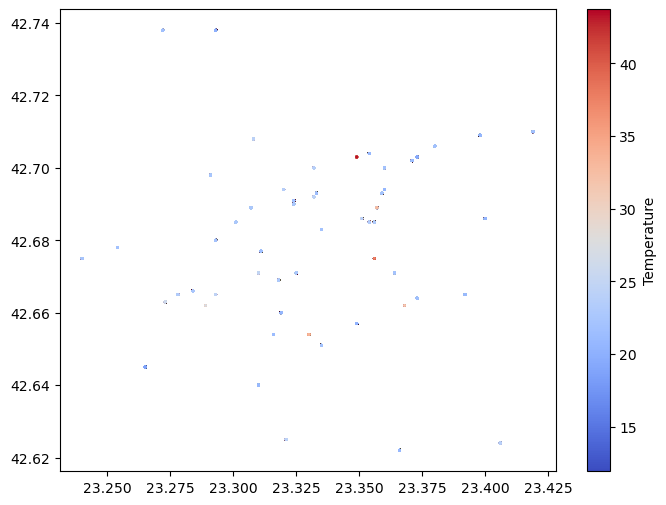

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(df['lon'], df['lat'], c=df['temperature'], cmap='coolwarm', s=1)
plt.colorbar(label='Temperature')
plt.show()

## Feature Engineering

In [17]:
df['humidity_pressure'] = df['humidity'] * df['pressure']
df['lat_lon'] = df['lat'] * df['lon']
df['pressure_temp_ratio'] = df['pressure'] / df['temperature']

## Data Preprocessing

In [18]:
# Drop any rows with missing values
df.dropna()

# Define features and target
X = df.drop('temperature', axis=1)
y = df['temperature']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling 

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

In [20]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)


## Evaluation


In [21]:
# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 1.5921466785489926
MAE: 1.2131896737912264
R2 Score: 0.9315795554242248


## Checking Model Overfitting

In [22]:
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

In [23]:
# Train performance
train_r2 = r2_score(y_train, y_train_pred_lr)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))

# Test performance
test_r2 = r2_score(y_test, y_test_pred_lr)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print("Train R2:", train_r2)
print("Test R2:", test_r2)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train R2: 0.931598511067111
Test R2: 0.9315795554242248
Train RMSE: 1.589709748037833
Test RMSE: 1.5921466785489926


In [24]:
# Model is not overfit

## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.


## Using Polynomial Regression

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [26]:
PR = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('lr', LinearRegression())
])

PR.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [27]:
y_pred_pr = PR.predict(X_test)

In [28]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_pr))
mae = mean_absolute_error(y_test, y_pred_pr)
r2 = r2_score(y_test, y_pred_pr)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.44155228657324497
MAE: 0.31877577996946904
R2 Score: 0.9947375980434399


## Checking Model Overfitting

In [29]:
y_train_pred_pr = PR.predict(X_train)
y_test_pred_pr = PR.predict(X_test)

In [30]:
# Train performance
train_r2 = r2_score(y_train, y_train_pred_pr)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_pr))

# Test performance
test_r2 = r2_score(y_test, y_test_pred_pr)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_pr))

print("Train R2:", train_r2)
print("Test R2:", test_r2)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train R2: 0.9947522428466691
Test R2: 0.9947375980434399
Train RMSE: 0.4403235608164467
Test RMSE: 0.44155228657324497


## Random Forest

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [33]:
y_pred_rf = rf.predict(X_test)

In [34]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.03548689606464418
MAE: 0.027777011469459177
R2 Score: 0.9999660096395174


## Checking Overfitting

In [35]:
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

In [36]:
# Train performance
train_r2 = r2_score(y_train, y_train_pred_rf)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))

# Test performance
test_r2 = r2_score(y_test, y_test_pred_rf)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print("Train R2:", train_r2)
print("Test R2:", test_r2)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train R2: 0.9999680666064642
Test R2: 0.9999660096395174
Train RMSE: 0.034348485767188776
Test RMSE: 0.03548689606464414


## XGBoost

In [37]:
from xgboost import XGBRegressor

In [38]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [43]:
y_pred_xgb = xgb.predict(X_test)

In [45]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.06621210547570382
MAE: 0.043128497154488445
R2 Score: 0.999881670089008


## Checking Overfitting

In [46]:
y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

In [47]:
# Train performance
train_r2 = r2_score(y_train, y_train_pred_xgb)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))

# Test performance
test_r2 = r2_score(y_test, y_test_pred_xgb)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

print("Train R2:", train_r2)
print("Test R2:", test_r2)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train R2: 0.9998964317135397
Test R2: 0.999881670089008
Train RMSE: 0.06185836760095071
Test RMSE: 0.06621210547570382


## Finding Best Model

In [49]:
from sklearn.metrics import r2_score

models = {
    "Linear Regression": lr,
    "Polynomial Regression": PR,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = {}

for name, model in models.items():
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Scores
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results[name] = test_r2
    
    print(f"{name}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2 : {test_r2:.4f}")
    print("-"*30)

# Best model based on test R2
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Best Test R2:", results[best_model])

Linear Regression
Train R2: 0.9316
Test R2 : 0.9316
------------------------------
Polynomial Regression
Train R2: 0.9948
Test R2 : 0.9947
------------------------------
Random Forest
Train R2: 1.0000
Test R2 : 1.0000
------------------------------
XGBoost
Train R2: 0.9999
Test R2 : 0.9999
------------------------------
Best Model: Random Forest
Best Test R2: 0.9999660096395174


## Detect Overfitting Gap

In [50]:
for name, model in models.items():
    
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    
    gap = train_r2 - test_r2
    
    print(f"{name} Overfitting Gap: {gap:.4f}")

Linear Regression Overfitting Gap: 0.0000
Polynomial Regression Overfitting Gap: 0.0000
Random Forest Overfitting Gap: 0.0000
XGBoost Overfitting Gap: 0.0000
